In [1]:
import pandas as pd

# Load the uploaded Excel file to check its structure
file_path = '../dataset/rab94row.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows to understand the structure
data.head()

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi
0,Gedung Apartemen,871000000000,606,DKI Jakarta,2021,68204.25309,6,120.020872,31,121.42,109.64,1.53
1,Gedung Apartemen,876000000000,605,DKI Jakarta,2021,68590.48909,6,120.617753,31,121.42,109.64,1.53
2,Gedung Apartemen,936000000000,649,DKI Jakarta,2020,73232.95902,6,128.564830,33,116.84,103.68,1.59
3,Gedung Apartemen,938000000000,628,DKI Jakarta,2020,73318.17099,6,128.882451,33,116.84,103.68,1.59
4,Gedung Apartemen,1050000000000,668,DKI Jakarta,2020,81640.56895,6,142.594757,36,116.84,103.68,1.59


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import BayesianRidge, Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [3]:
import numpy as np

numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Retry applying log transformation with numpy properly imported
transformed_data = data.copy()
for col in numerical_columns:
    transformed_data[col] = data[col].apply(lambda x: np.log1p(x) if x > 0 else x)

In [4]:
transformed_data.head()

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi
0,Gedung Apartemen,27.492908,6.408529,DKI Jakarta,7.611842,11.130277,1.94591,4.795963,3.465736,4.807458,4.706282,0.928219
1,Gedung Apartemen,27.498632,6.406880,DKI Jakarta,7.611842,11.135924,1.94591,4.800883,3.465736,4.807458,4.706282,0.928219
2,Gedung Apartemen,27.564881,6.476972,DKI Jakarta,7.611348,11.201415,1.94591,4.864181,3.526361,4.769328,4.650908,0.951658
3,Gedung Apartemen,27.567016,6.444131,DKI Jakarta,7.611348,11.202577,1.94591,4.866630,3.526361,4.769328,4.650908,0.951658
4,Gedung Apartemen,27.679811,6.505784,DKI Jakarta,7.611348,11.310094,1.94591,4.966995,3.610918,4.769328,4.650908,0.951658


In [5]:
cekduplikat = transformed_data[transformed_data.duplicated()]
cekduplikat

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi


In [6]:
transformed_data = transformed_data.drop_duplicates()

cekduplikat = transformed_data[transformed_data.duplicated()]
cekduplikat, transformed_data.shape

(Empty DataFrame
 Columns: [namaproyek, rab, waktu, provinsi, tahun, luas, subitem, tinggi, lantai, ikk, ihbp, inflasi]
 Index: [],
 (94, 12))

In [7]:
# Fungsi untuk mendeteksi outlier menggunakan metode IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analisis outlier untuk setiap kolom numerik
outlier_results = {}
for col in numerical_columns:
    outliers, lower, upper = detect_outliers_iqr(transformed_data, col)
    outlier_results[col] = {
        "outliers_count": len(outliers),
        "lower_bound": lower,
        "upper_bound": upper
    }

# Menampilkan hasil analisis outlier
outlier_results

{'rab': {'outliers_count': 4,
  'lower_bound': 27.226348212429848,
  'upper_bound': 27.996962523847053},
 'waktu': {'outliers_count': 1,
  'lower_bound': 6.276350172435078,
  'upper_bound': 6.664825557243586},
 'tahun': {'outliers_count': 0,
  'lower_bound': 7.60788543037709,
  'upper_bound': 7.615798390425516},
 'luas': {'outliers_count': 4,
  'lower_bound': 10.874644684051724,
  'upper_bound': 11.6179529767102},
 'subitem': {'outliers_count': 1,
  'lower_bound': 1.9459101490553132,
  'upper_bound': 1.9459101490553132},
 'tinggi': {'outliers_count': 2,
  'lower_bound': 4.565729729459754,
  'upper_bound': 5.231677846300954},
 'lantai': {'outliers_count': 1,
  'lower_bound': 3.207960517409738,
  'upper_bound': 3.8953615451163746},
 'ikk': {'outliers_count': 0,
  'lower_bound': 4.47807790014296,
  'upper_bound': 4.922348350649209},
 'ihbp': {'outliers_count': 0,
  'lower_bound': 4.255595659957586,
  'upper_bound': 5.406323949764713},
 'inflasi': {'outliers_count': 7,
  'lower_bound': 0.7

In [8]:
# Fungsi untuk mendeteksi dan menghapus baris yang mengandung outlier
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hapus baris yang memiliki nilai outlier
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Hapus outlier untuk setiap kolom numerik
data_cleaned = transformed_data.copy()
for col in numerical_columns:
    data_cleaned = remove_outliers_iqr(data_cleaned, col)

In [9]:
data_cleaned.shape

(82, 12)

In [10]:
# Label encoding kolom 'Provinsi' dan nama proyek karena nilainya kategorikal
label_encoder = LabelEncoder()
data_cleaned['label_provinsi'] = label_encoder.fit_transform(data_cleaned['provinsi'])
data_cleaned['label_namaproyek'] = label_encoder.fit_transform(data_cleaned['namaproyek'])

# Melihat nilai unik dari hasil encoding kolom 'provinsi_encoded'
provinsi_unik = data_cleaned[['provinsi', 'label_provinsi']].drop_duplicates().sort_values(
    by='label_provinsi')

# Melihat nilai unik dari hasil encoding kolom 'namaproyek_encoded'
namaproyek_unik = data_cleaned[['namaproyek', 'label_namaproyek']].drop_duplicates().sort_values(
    by='label_namaproyek')

In [11]:
provinsi_unik

,provinsi,label_provinsi
90,Bali,0
77,Banten,1
0,DKI Jakarta,2
39,Jawa Barat,3
68,Jawa Timur,4
85,Kalimantan Timur,5


In [12]:
namaproyek_unik

,namaproyek,label_namaproyek
0,Gedung Apartemen,0


In [13]:
# 4. Normalisasi Kolom Numerik
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

numerical_columns = ['waktu', 'tahun', 'luas', 'subitem', 
                     'tinggi', 'lantai', 'ikk', 'ihbp', 'inflasi']
# 4. Normalisasi Kolom Numerik
scalerMinMax = MinMaxScaler()
data_cleaned[numerical_columns] = scalerMinMax.fit_transform(data_cleaned[numerical_columns])

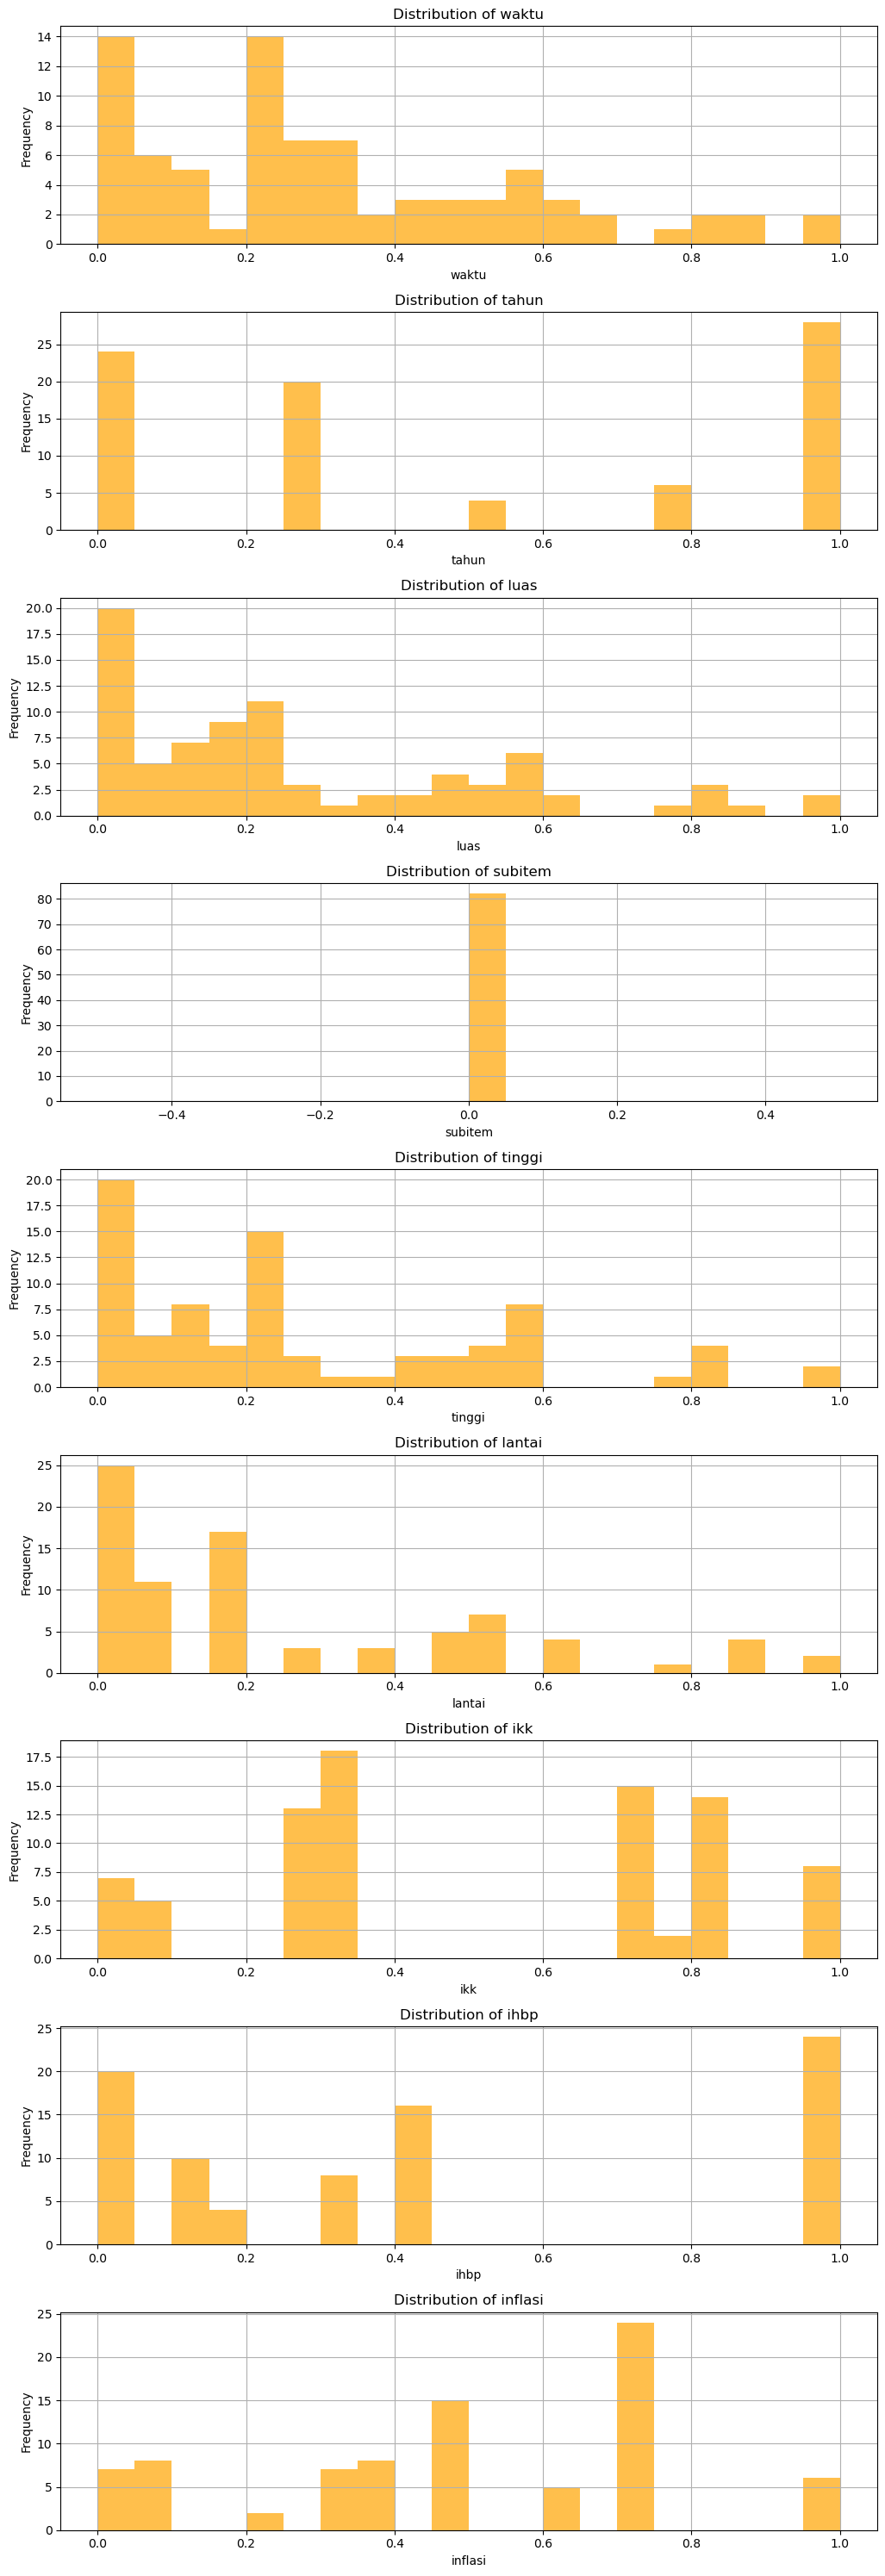

In [14]:
# Compare distributions before and after transformation using histograms
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_columns, 1):

    # Transformed data
    plt.subplot(len(numerical_columns), 2, 2 * i)
    data_cleaned[col].hist(bins=20, alpha=0.7, color='orange')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

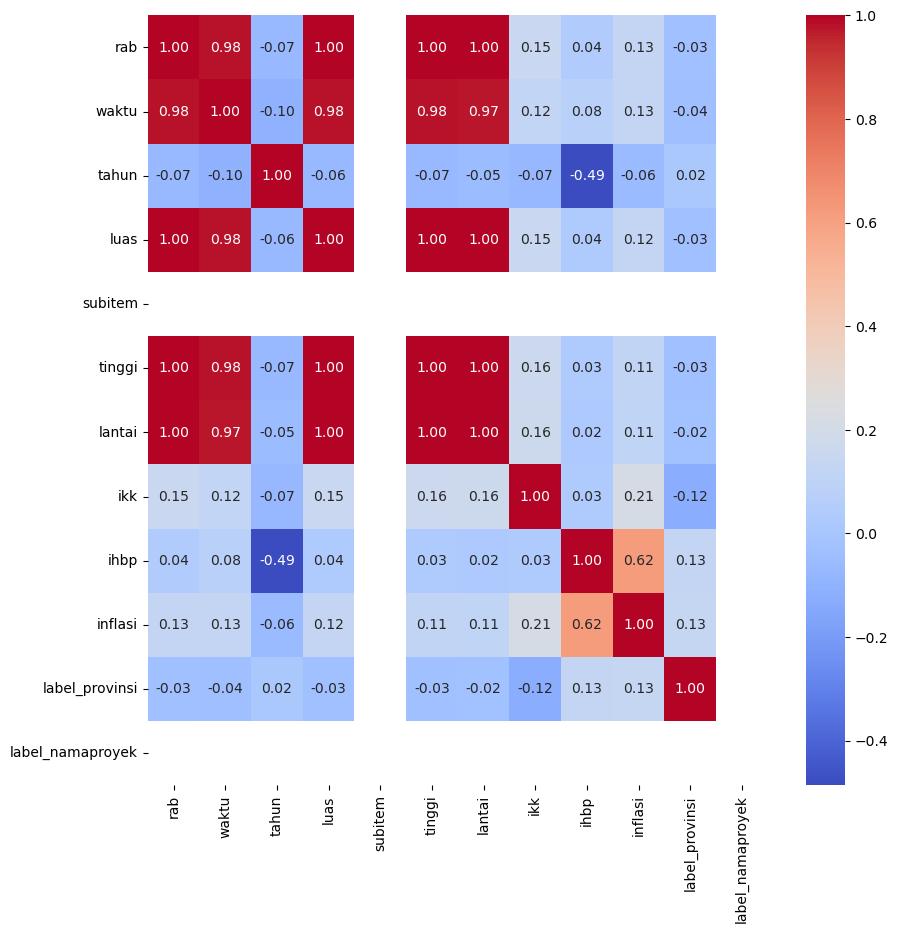

In [15]:
# Digunakan untuk membuat visualisasi dalam bentuk grafik atau plot
import seaborn as sns
import matplotlib.pyplot as plt
# Visualisasi korelasi antar fitur atau kolom apakah saling berpengaruh atau tidak
fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(data_cleaned.corr(numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.show()

In [16]:
# Split data into features and target
X1 = data_cleaned.drop(columns=[
    'rab', 'namaproyek', 'provinsi', 'lantai'])
y1 = data_cleaned['rab']

# Split into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, 
    test_size=0.3, 
    random_state=42)

# Split into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y1, 
    test_size=0.2, 
    random_state=42)

In [17]:
# Initialize models
models1 = {
    'AdaBoost': AdaBoostRegressor(),
    'Bayesian Ridge': BayesianRidge(),
    'Decision Tree': DecisionTreeRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'KNN Regressor': KNeighborsRegressor(),
    'Lasso Regression': Lasso(),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Ridge Regression': Ridge(),
    'SVR': SVR(),
    'XGBoost': xgb.XGBRegressor()
}

models2 = {
    'AdaBoost': AdaBoostRegressor(),
    'Bayesian Ridge': BayesianRidge(),
    'Decision Tree': DecisionTreeRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'KNN Regressor': KNeighborsRegressor(),
    'Lasso Regression': Lasso(),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Ridge Regression': Ridge(),
    'SVR': SVR(),
    'XGBoost': xgb.XGBRegressor()
}

# 70:30
# Train and evaluate each model with additional metrics
results1 = []
for name1, model1 in models1.items():
    # Fit model to training data
    model1.fit(X_train1, y_train1)
    
    # Predict on training data
    y_train_pred1 = model1.predict(X_train1)
    
    # Predict on testing data
    y_pred1 = model1.predict(X_test1)
    
    # Calculate metrics for training data
    r2_train1 = r2_score(y_train1, y_train_pred1)
    
    # Calculate metrics for testing data
    mse1 = mean_squared_error(y_test1, y_pred1)
    mae1 = mean_absolute_error(y_test1, y_pred1)
    r21 = r2_score(y_test1, y_pred1)
    
    # Append results
    results1.append({
        'Model': name1,
        'Training R2 Score': r2_train1,
        'Testing RMSE': np.sqrt(mse1),
        'Testing MAE': mae1,
        'Testing R2 Score': r21
    })

# Convert results into a DataFrame for better visualization
results_df1 = pd.DataFrame(results1).sort_values(by='Testing R2 Score', ascending=False)

# 80:20
# Train and evaluate each model with additional metrics
results2 = []
for name2, model2 in models2.items():
    # Fit model to training data
    model2.fit(X_train2, y_train2)
    
    # Predict on training data
    y_train_pred2 = model2.predict(X_train2)
    
    # Predict on testing data
    y_pred2 = model2.predict(X_test2)
    
    # Calculate metrics for training data
    r2_train2 = r2_score(y_train2, y_train_pred2)
    
    # Calculate metrics for testing data
    mse2 = mean_squared_error(y_test2, y_pred2)
    mae2 = mean_absolute_error(y_test2, y_pred2)
    r22 = r2_score(y_test2, y_pred2)
    
    # Append results
    results2.append({
        'Model': name2,
        'Training R2 Score': r2_train2,
        'Testing RMSE': np.sqrt(mse2),
        'Testing MAE': mae2,
        'Testing R2 Score': r22
    })

# Convert results into a DataFrame for better visualization
results_df2 = pd.DataFrame(results2).sort_values(by='Testing R2 Score', ascending=False)


In [18]:
results_df1

,Model,Training R2 Score,Testing RMSE,Testing MAE,Testing R2 Score
1,Bayesian Ridge,0.999804,0.002139,0.001461,0.999662
6,Linear Regression,0.999804,0.002158,0.001462,0.999656
0,AdaBoost,0.998182,0.004462,0.003380,0.998530
3,Gradient Boosting,1.000000,0.005865,0.003761,0.997460
2,Decision Tree,1.000000,0.008338,0.004990,0.994868
7,Random Forest,0.997747,0.009196,0.004931,0.993756
8,Ridge Regression,0.987321,0.012591,0.009370,0.988296
10,XGBoost,0.999982,0.021614,0.012093,0.965512
9,SVR,0.537577,0.082005,0.069868,0.503533
4,KNN Regressor,0.747277,0.087331,0.061076,0.436944


In [19]:
results_df2

,Model,Training R2 Score,Testing RMSE,Testing MAE,Testing R2 Score
1,Bayesian Ridge,0.999751,0.001524,0.001038,0.999803
6,Linear Regression,0.999752,0.001530,0.001034,0.999801
0,AdaBoost,0.998128,0.005050,0.003918,0.997833
3,Gradient Boosting,1.000000,0.005284,0.003564,0.997628
7,Random Forest,0.998540,0.005676,0.003869,0.997263
8,Ridge Regression,0.990210,0.009916,0.007234,0.991644
2,Decision Tree,1.000000,0.013822,0.008106,0.983767
10,XGBoost,0.999982,0.020807,0.011376,0.963212
4,KNN Regressor,0.693114,0.054375,0.043301,0.748771
9,SVR,0.595098,0.076189,0.072238,0.506770


In [20]:
# Ambil model terbaik dari split data 70:30
best_model_name1 = results_df1.iloc[0]['Model']
best_model1 = models1[best_model_name1]

# Ambil model terbaik dari split data 80:20
best_model_name2 = results_df2.iloc[0]['Model']
best_model2 = models2[best_model_name2]


In [21]:
# Prediksi nilai actual dan prediksi untuk 70:30
y_actual1 = y_test1
y_pred_best1 = best_model1.predict(X_test1)

# Prediksi nilai actual dan prediksi untuk 80:20
y_actual2 = y_test2
y_pred_best2 = best_model2.predict(X_test2)


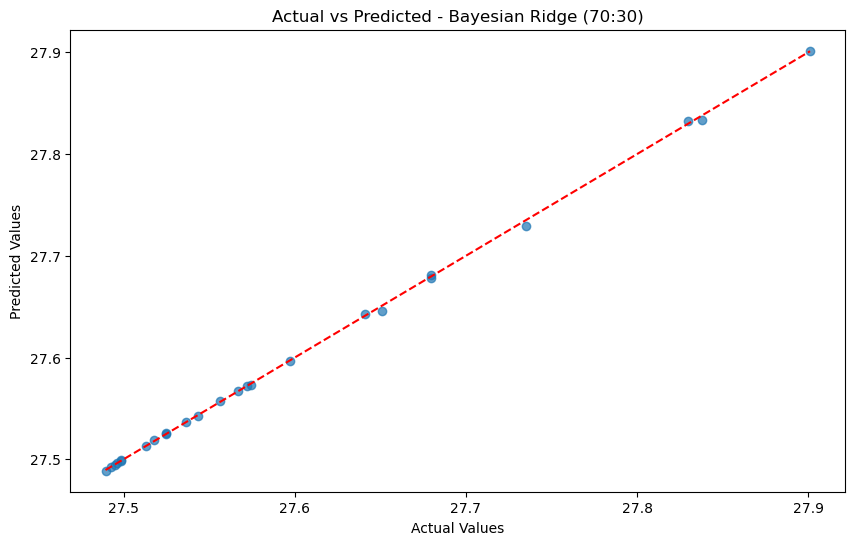

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_actual1, y_pred_best1, alpha=0.7)
plt.plot([y_actual1.min(), y_actual1.max()], [y_actual1.min(), y_actual1.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name1} (70:30)")
plt.show()


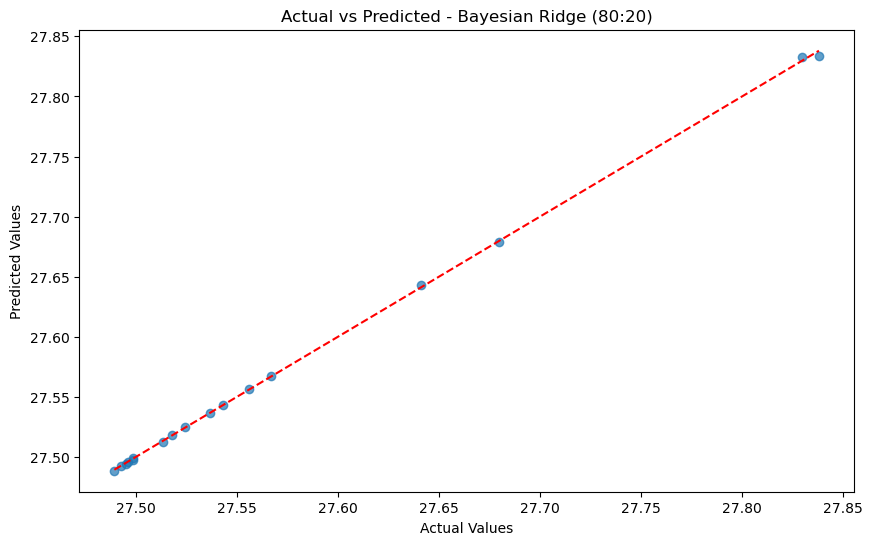

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(y_actual2, y_pred_best2, alpha=0.7)
plt.plot([y_actual2.min(), y_actual2.max()], [y_actual2.min(), y_actual2.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name2} (80:20)")
plt.show()


In [24]:
# Dataframe untuk 70:30
comparison1 = pd.DataFrame({'Actual': y_actual1, 'Predicted': y_pred_best1})

# Dataframe untuk 80:20
comparison2 = pd.DataFrame({'Actual': y_actual2, 'Predicted': y_pred_best2})

# Tampilkan beberapa baris pertama
print(comparison1.head())
print(comparison2.head())


       Actual  Predicted
30  27.838035  27.833323
0   27.492908  27.492263
22  27.556298  27.557227
33  27.567016  27.567086
18  27.517852  27.518752
       Actual  Predicted
30  27.838035  27.833501
0   27.492908  27.492442
22  27.556298  27.556913
33  27.567016  27.567059
18  27.517852  27.518555


In [25]:
# Kembalikan nilai log ke bentuk asli
comparison1['Actual (Original)'] = np.exp(comparison1['Actual'])
comparison1['Predicted (Original)'] = np.exp(comparison1['Predicted'])

comparison2['Actual (Original)'] = np.exp(comparison2['Actual'])
comparison2['Predicted (Original)'] = np.exp(comparison2['Predicted'])

# Format ke dalam Rupiah
def format_rupiah(value):
    return f"Rp {value:,.0f}".replace(",", ".")

comparison1['Actual (Rupiah)'] = comparison1['Actual (Original)'].apply(format_rupiah)
comparison1['Predicted (Rupiah)'] = comparison1['Predicted (Original)'].apply(format_rupiah)

comparison2['Actual (Rupiah)'] = comparison2['Actual (Original)'].apply(format_rupiah)
comparison2['Predicted (Rupiah)'] = comparison2['Predicted (Original)'].apply(format_rupiah)

# Tampilkan beberapa baris pertama
print(comparison1[['Actual (Rupiah)', 'Predicted (Rupiah)']])
print()
print("*" * 100)
print(comparison2[['Actual (Rupiah)', 'Predicted (Rupiah)']])


         Actual (Rupiah)    Predicted (Rupiah)
30  Rp 1.230.000.000.001  Rp 1.224.218.046.603
0     Rp 871.000.000.001    Rp 870.438.541.257
22    Rp 928.000.000.001    Rp 928.862.753.626
33    Rp 938.000.000.001    Rp 938.065.518.570
18    Rp 893.000.000.001    Rp 893.803.654.918
28  Rp 1.010.000.000.001  Rp 1.011.930.336.192
10    Rp 868.000.000.001    Rp 867.408.228.391
57    Rp 889.000.000.001    Rp 888.571.552.184
4   Rp 1.050.000.000.001  Rp 1.047.918.737.338
12    Rp 874.000.000.001    Rp 873.770.588.297
52    Rp 876.000.000.001    Rp 875.481.211.753
35    Rp 876.000.000.001    Rp 876.879.656.893
72    Rp 873.000.000.001    Rp 871.988.111.511
37  Rp 1.220.000.000.001  Rp 1.223.568.896.695
77    Rp 916.000.000.001    Rp 915.345.394.703
48    Rp 910.000.000.001    Rp 910.386.910.197
83    Rp 899.000.000.001    Rp 898.915.296.288
66  Rp 1.050.000.000.001  Rp 1.051.633.150.735
60    Rp 967.000.000.001    Rp 966.532.200.830
42  Rp 1.110.000.000.001  Rp 1.103.510.391.684
9     Rp 943.

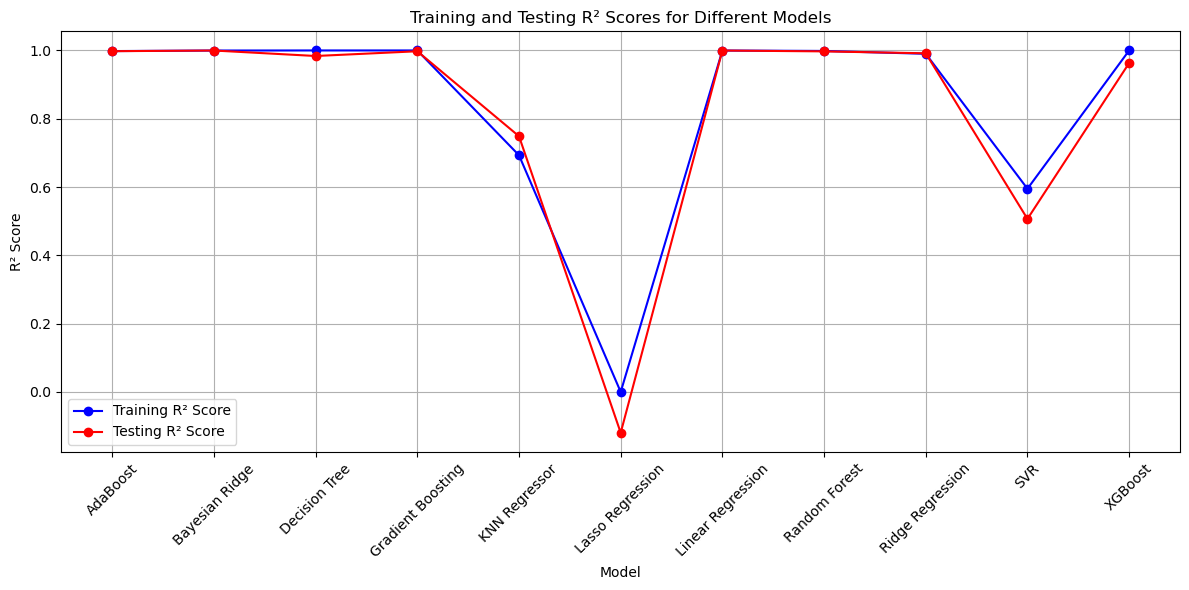

In [26]:
import matplotlib.pyplot as plt

# Extract model names and their corresponding R² scores
model_names = [r['Model'] for r in results2]
train_r2_scores = [r['Training R2 Score'] for r in results2]
test_r2_scores = [r['Testing R2 Score'] for r in results2]


# Set the figure size
plt.figure(figsize=(12, 6))

# Plot Training R² Scores
plt.plot(model_names, train_r2_scores, 'bo-', label='Training R² Score')

# Plot Testing R² Scores
plt.plot(model_names, test_r2_scores, 'ro-', label='Testing R² Score')

# Customize the plot
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Training and Testing R² Scores for Different Models')
plt.xticks(rotation=45)  # Rotate model names for better visibility
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


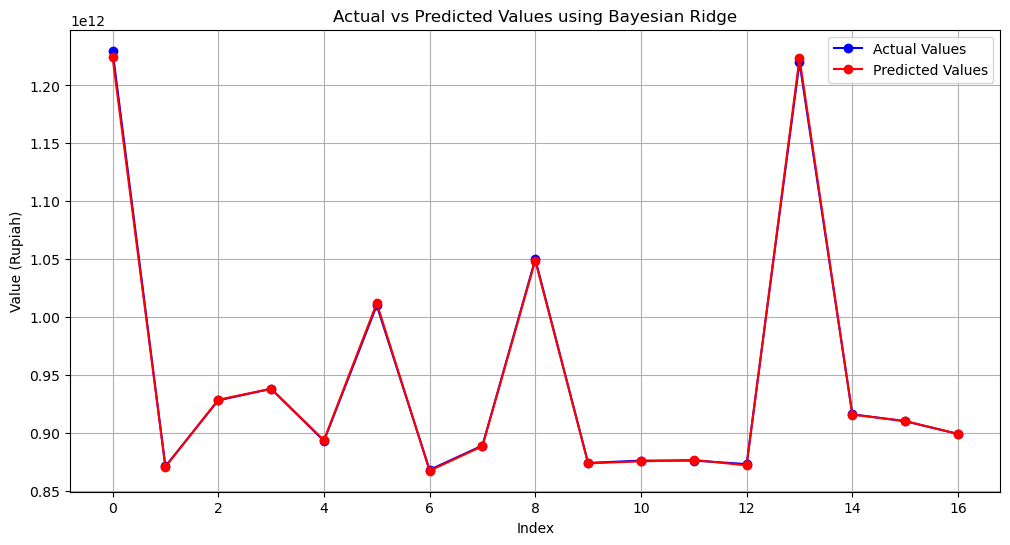

In [27]:
# Identify the best model based on Testing R² Score
best_model_name = results_df2.iloc[0]['Model']
best_model = models2[best_model_name]

# Predict on the test data
y_pred_log = best_model.predict(X_test2)

# If your target variable was log-transformed, revert it back
y_actual = np.exp(y_test2.reset_index(drop=True))
y_pred = np.exp(y_pred_log)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_actual,
    'Predicted': y_pred
})

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 'bo-', label='Actual Values')
plt.plot(comparison_df.index, comparison_df['Predicted'], 'ro-', label='Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value (Rupiah)')
plt.title(f'Actual vs Predicted Values using {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()


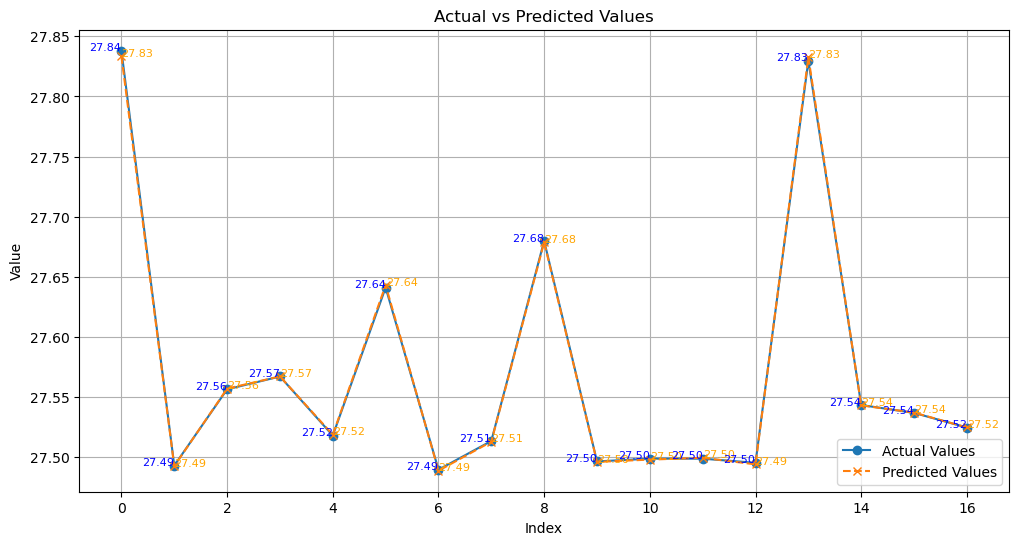

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Pastikan data berbentuk array (jika tidak, ubah dengan np.array)
y_test = np.array(y_test2)  # Nilai aktual
y_pred = np.array(y_pred_log)  # Nilai prediksi

# Buat plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test, label='Actual Values', marker='o', linestyle='-')
plt.plot(range(len(y_pred)), y_pred, label='Predicted Values', marker='x', linestyle='--')

# Tambahkan angka di setiap titik
for i, (y_actual, y_predict) in enumerate(zip(y_test, y_pred)):
    plt.text(i, y_actual, f'{y_actual:.2f}', fontsize=8, ha='right', color='blue')
    plt.text(i, y_predict, f'{y_predict:.2f}', fontsize=8, ha='left', color='orange')

# Tambahkan label dan judul
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)

# Tampilkan plot
plt.show()

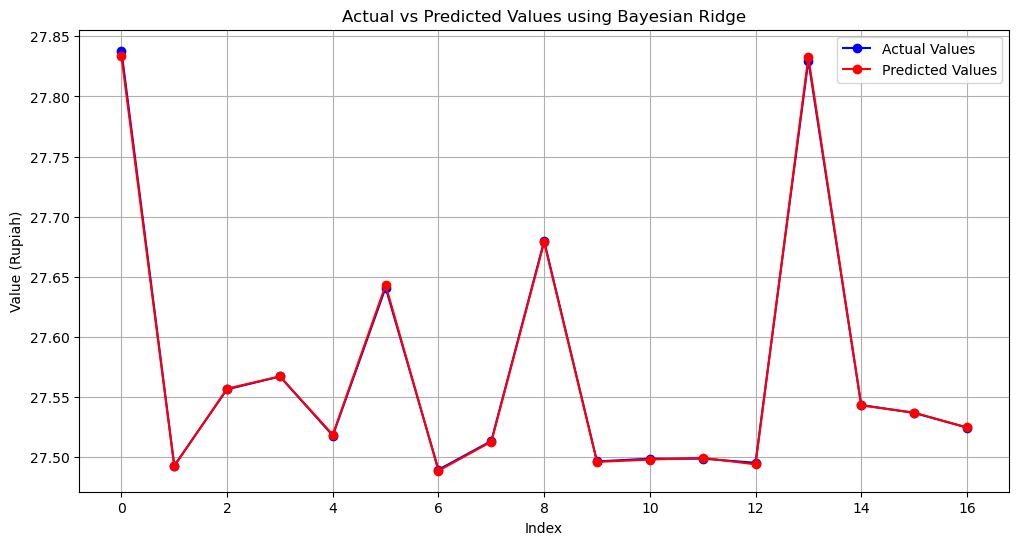

In [29]:
# Identify the best model based on Testing R² Score
best_model_name = results_df2.iloc[0]['Model']
best_model = models2[best_model_name]

# Predict on the test data
y_pred = best_model.predict(X_test2)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_test2.reset_index(drop=True),
    'Predicted': y_pred
})

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 'bo-', label='Actual Values')
plt.plot(comparison_df.index, comparison_df['Predicted'], 'ro-', label='Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value (Rupiah)')
plt.title(f'Actual vs Predicted Values using {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()


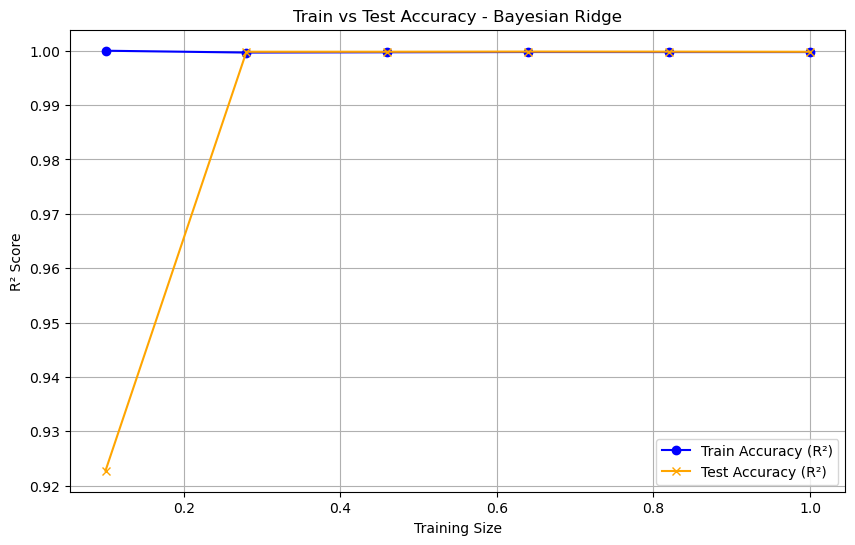

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Model terbaik dari results_df1
best_model_name = results_df2.iloc[0]['Model']
best_model = models2[best_model_name]

# Training sizes (misalnya dalam persen data training)
training_sizes = np.linspace(0.1, 1.0, 6)

# Menyimpan nilai R² untuk setiap training size
train_accuracies_best = []
test_accuracies_best = []

for size in training_sizes:
    # Tentukan jumlah data training sesuai ukuran
    train_size = int(size * len(X_train2))
    X_train_subset = X_train2[:train_size]
    y_train_subset = y_train2[:train_size]
    
    # Fit model dengan subset data
    best_model.fit(X_train_subset, y_train_subset)
    
    # Prediksi untuk data training dan testing
    y_train_pred = best_model.predict(X_train_subset)
    y_test_pred = best_model.predict(X_test2)
    
    # Hitung R² Score
    train_accuracies_best.append(r2_score(y_train_subset, y_train_pred))
    test_accuracies_best.append(r2_score(y_test2, y_test_pred))

# Plot Train vs Test Accuracy khusus model terbaik
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, train_accuracies_best, 'bo-', label='Train Accuracy (R²)')
plt.plot(training_sizes, test_accuracies_best, 'x-', color='orange', label='Test Accuracy (R²)')
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.title(f'Train vs Test Accuracy - {best_model_name}')
plt.grid(True)
plt.legend()
plt.show()


In [31]:
from sklearn.model_selection import cross_val_score

# Model terbaik
best_model_name = results_df2.iloc[0]['Model']
best_model = models2[best_model_name]

# Cross-validation
cv_folds = 5  # Jumlah lipatan (folds)
cv_scores = cross_val_score(best_model, X_train2, y_train2, cv=cv_folds, scoring='r2')

# Rata-rata dan standar deviasi R² Score dari cross-validation
mean_cv_score = np.mean(cv_scores)
std_cv_score = np.std(cv_scores)

# Tampilkan hasil
print(f"Cross-Validation Scores (R²): {cv_scores}")
print(f"Mean R² Score: {mean_cv_score:.4f}")
print(f"Standard Deviation: {std_cv_score:.4f}")


Cross-Validation Scores (R²): [0.99952285 0.9995817  0.99972323 0.99988792 0.99960249]
Mean R² Score: 0.9997
Standard Deviation: 0.0001


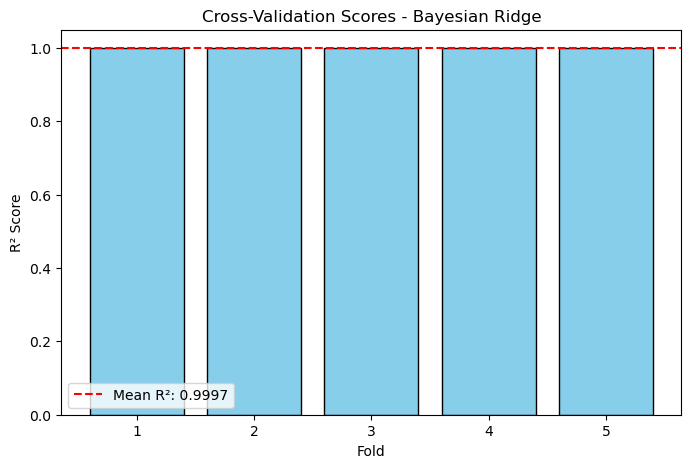

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, cv_folds + 1), cv_scores, color='skyblue', edgecolor='black')
plt.axhline(y=mean_cv_score, color='red', linestyle='--', label=f"Mean R²: {mean_cv_score:.4f}")
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title(f'Cross-Validation Scores - {best_model_name}')
plt.legend()
plt.show()


Yang tinggi bayesian ridge jadi iseng aja lakuin tuning xgboost regressor

In [33]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Definisikan parameter yang akan dituning untuk model XGBoost
param_grid = {
    'n_estimators': [50, 100, 200, 300],       # Jumlah estimators
    'learning_rate': [0.01, 0.1, 0.2, 0.3],   # Learning rate
    'max_depth': [3, 5, 7, 9],                # Maksimum kedalaman pohon
    'subsample': [0.6, 0.8, 1.0],             # Proporsi sampel untuk membangun setiap pohon
    'colsample_bytree': [0.6, 0.8, 1.0],      # Proporsi fitur yang digunakan untuk setiap pohon
    'gamma': [0, 1, 5],                       # Minimum reduction loss untuk split
    'reg_alpha': [0, 0.1, 1],                 # Regularisasi L1
    'reg_lambda': [1, 2, 5]                   # Regularisasi L2
}

# Inisialisasi model XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='r2', verbose=1, n_jobs=-1)

# Jalankan GridSearchCV
grid_search.fit(X_train2, y_train2)

# Hasil terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation R² Score: {best_score:.4f}")


Fitting 5 folds for each of 15552 candidates, totalling 77760 fits
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
Best Cross-Validation R² Score: 0.9876


In [34]:
# Model dengan parameter terbaik
best_model_tuned = xgb.XGBRegressor(**best_params)
best_model_tuned.fit(X_train2, y_train2)

# Prediksi pada data testing
y_pred_tuned = best_model_tuned.predict(X_test2)

# Evaluasi performa
r2_tuned = r2_score(y_test2, y_pred_tuned)
print(f"Testing R² Score (Tuned Model): {r2_tuned:.4f}")


Testing R² Score (Tuned Model): 0.9754


Testing R² Score (Tuned Model): 0.9754


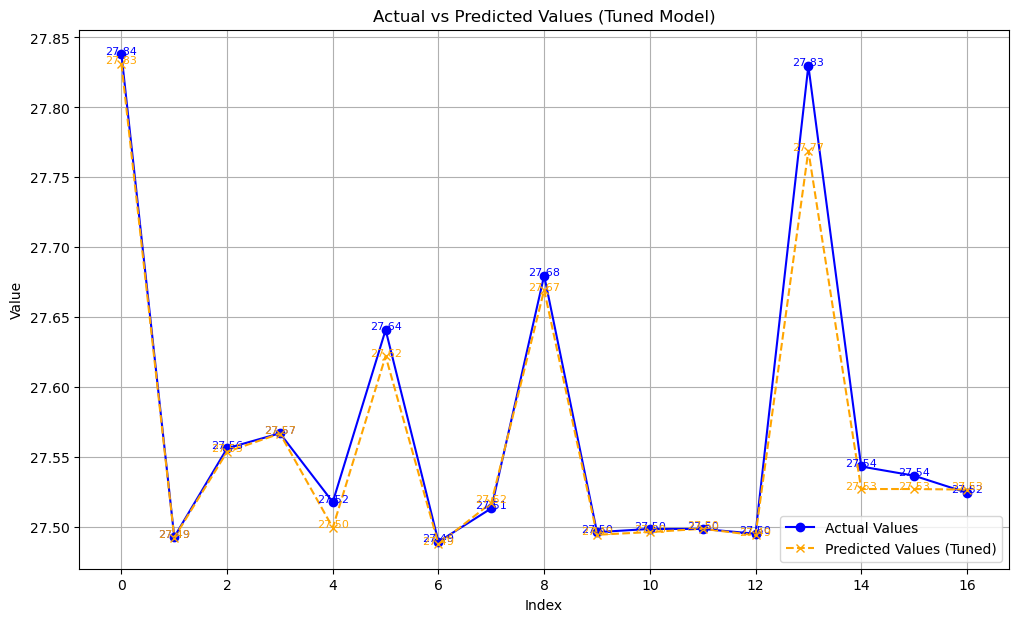

In [35]:
import matplotlib.pyplot as plt

# Model dengan parameter terbaik setelah tuning
best_model_tuned = xgb.XGBRegressor(**grid_search.best_params_)
best_model_tuned.fit(X_train2, y_train2)

# Prediksi pada data testing
y_pred_tuned = best_model_tuned.predict(X_test2)

# Evaluasi performa
r2_tuned = r2_score(y_test2, y_pred_tuned)
print(f"Testing R² Score (Tuned Model): {r2_tuned:.4f}")

# Visualisasi Hasil: Actual vs Predicted
plt.figure(figsize=(12, 7))
plt.plot(range(len(y_test2)), y_test2, 'o-', label='Actual Values', color='blue')
plt.plot(range(len(y_pred_tuned)), y_pred_tuned, 'x--', label='Predicted Values (Tuned)', color='orange')
for i, (a, p) in enumerate(zip(y_test2, y_pred_tuned)):
    plt.text(i, a, f"{a:.2f}", color="blue", fontsize=8, ha='center')
    plt.text(i, p, f"{p:.2f}", color="orange", fontsize=8, ha='center')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values (Tuned Model)')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
print("Best Parameters after Tuning:", grid_search.best_params_)


Best Parameters after Tuning: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}


Testing R² Score (Tuned Model): 0.9703


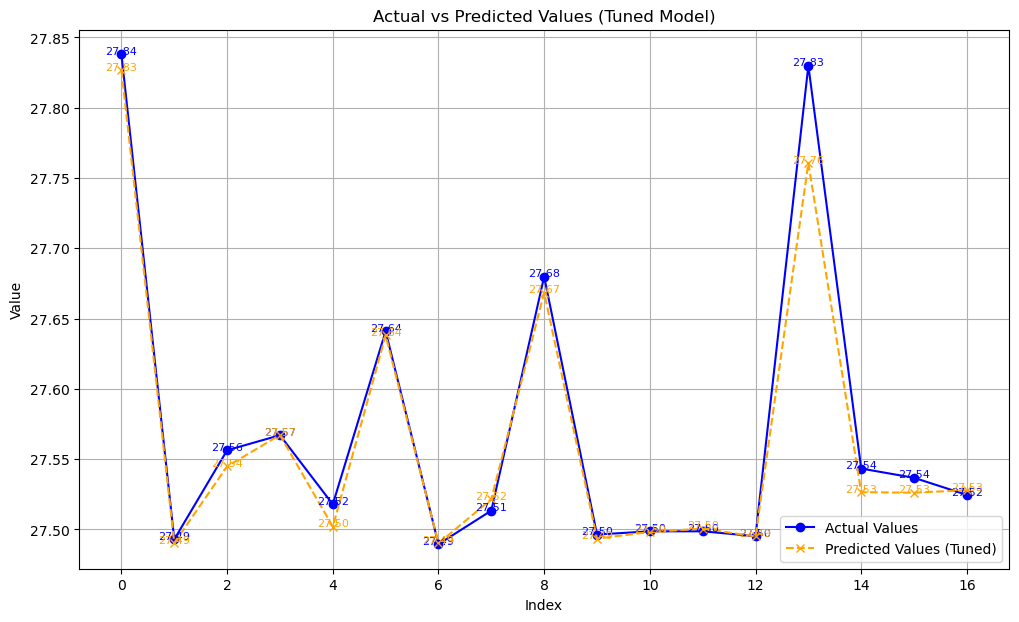

In [37]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree= 1.0, 
    gamma= 0, 
    learning_rate= 0.1, 
    max_depth= 3, 
    n_estimators= 100, 
    reg_alpha= 0, 
    reg_lambda= 2, 
    subsample= 0.6
)

xgb_model.fit(X_train2, y_train2)

# Prediksi pada data testing
y_pred_tuned = xgb_model.predict(X_test2)

# Evaluasi performa
r2_tuned = r2_score(y_test2, y_pred_tuned)
print(f"Testing R² Score (Tuned Model): {r2_tuned:.4f}")

# Visualisasi Hasil: Actual vs Predicted
plt.figure(figsize=(12, 7))
plt.plot(range(len(y_test2)), y_test2, 'o-', label='Actual Values', color='blue')
plt.plot(range(len(y_pred_tuned)), y_pred_tuned, 'x--', label='Predicted Values (Tuned)', color='orange')
for i, (a, p) in enumerate(zip(y_test2, y_pred_tuned)):
    plt.text(i, a, f"{a:.2f}", color="blue", fontsize=8, ha='center')
    plt.text(i, p, f"{p:.2f}", color="orange", fontsize=8, ha='center')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values (Tuned Model)')
plt.legend()
plt.grid(True)
plt.show()